In [5]:
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

In [ ]:
root_path = Path.cwd().parent
path_data = "data_splits/data_splits.csv"
path_images = "data/raw"


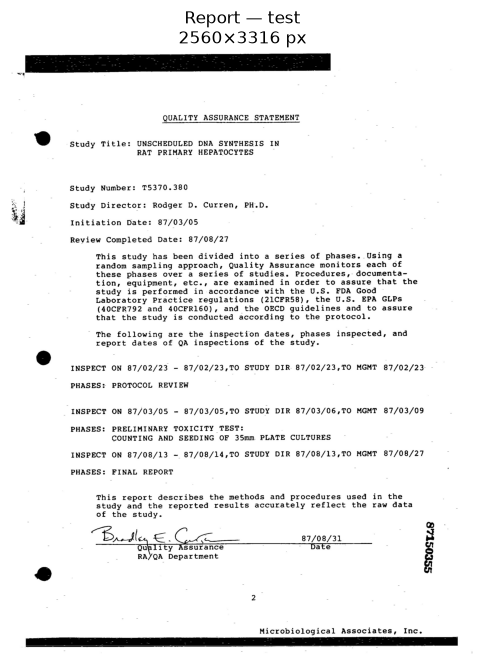

In [11]:
df = pd.read_csv(root_path /path_data)

line = df.sample(1).iloc[0]

img = Image.open(root_path / path_images / line["path"])
plt.figure(figsize=(6, 8))
plt.imshow(img, cmap="gray")
plt.title(f"{line['label']} — {line['split']}\n{img.size[0]}×{img.size[1]} px")
plt.axis("off")
plt.show()

In [13]:
import pytesseract

text = pytesseract.image_to_string(img)

print(f"Class : {line['label']} | {line['path']}")
print("-" * 60)
print(text)

Class : Report | train/87150355.jpg
------------------------------------------------------------
QUALITY ASSURANCE STATEMENT

“Study Title: UNSCHEDULED DNA SYNTHESIS IN

RAT PRIMARY HEPATOCYTES

Study Number: 1T5370.380

Study Director: Rodger D. Curren, PH.D.

Initiation Date: 87/03/05

Review Completed Date: 87/08/27

This study has been divided into a series of phases. Using a
random sampling approach, Quality Assurance monitors each of
these phases over a series of studies. Procedures, documenta-
tion, equipment, etc., are examined in order to assure that the
study is performed in-accordance with the U.S. FDA Good
Laboratory Practice regulations (21CFR58), the U.S. EPA GLPs
(40CFR792 and 40CFR160), and the OECD guidelines and to assure
that the study is conducted according to the protocol.

- The following are the inspection dates, phases inspected, and
report dates of QA inspections of the study.

INSPECT ON 87/02/23 - 87/02/23,TO STUDY DIR. 87/02/23,TO MGMT 87/02/23 -__

PHASES: 

In [28]:
from tqdm.auto import tqdm

N_PER_CLASSE = 2
sample = df.groupby("label").sample(N_PER_CLASSE, random_state=0)

results = []
for _, line in tqdm(sample.iterrows(), total=len(sample)):
    img = Image.open(root_path / path_images / line["path"])
    text = pytesseract.image_to_string(img)
    
    # Tesseract's average confidence score for recognized words (0 to 100)
    data = pytesseract.image_to_data(img, output_type=pytesseract.Output.DATAFRAME)
    words = data[(data["conf"] > 0) & data["text"].notna() & (data["text"].str.strip() != "")]
    
    results.append({
        "label": line["label"],
        "path": line["path"],
        "nb_caracters": len(text.strip()),
        "nb_words": len(words),
        "confidence": words["conf"].mean() if len(words) else 0,
        "text": text,
    })
    
ocr = pd.DataFrame(results)

100%|██████████| 20/20 [00:38<00:00,  1.94s/it]


In [15]:
df['label'].unique()

<StringArray>
[     'Email',       'ADVE', 'Scientific',     'Resume',     'Letter',
       'Note',       'Form',       'Memo',     'Report',       'News']
Length: 10, dtype: str

In [ ]:
import textwrap
import numpy as np

def display_class(ocr, label, max_caracteres=800):
    groupe = ocr[ocr["label"] == label]
    if groupe.empty:
        print(f"Classe '{label}' Not found. Classes availables: {sorted(ocr['label'].unique())}")
        return

    n = len(groupe)
    fig, axes = plt.subplots(n, 2, figsize=(14, 6 * n), gridspec_kw={"width_ratios": [1, 1.3]})
    axes = np.atleast_2d(axes)

    for (ax_img, ax_txt), (_, r) in zip(axes, groupe.iterrows()):
        ax_img.imshow(Image.open(root_path / path_images / r["path"]), cmap="gray")
        ax_img.set_title(f"{r['nb_words']} words — confidence {r['confidence']:.0f}", fontsize=10)
        ax_img.axis("off")

        text = r["text"].strip()[:max_caracteres] or "(no text recognized)"
        text= "\n".join(textwrap.fill(l, 80) for l in text.splitlines() if l.strip())
        ax_txt.text(0, 1, text, va="top", ha="left", family="monospace", fontsize=8)
        ax_txt.axis("off")

    fig.suptitle(label, fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

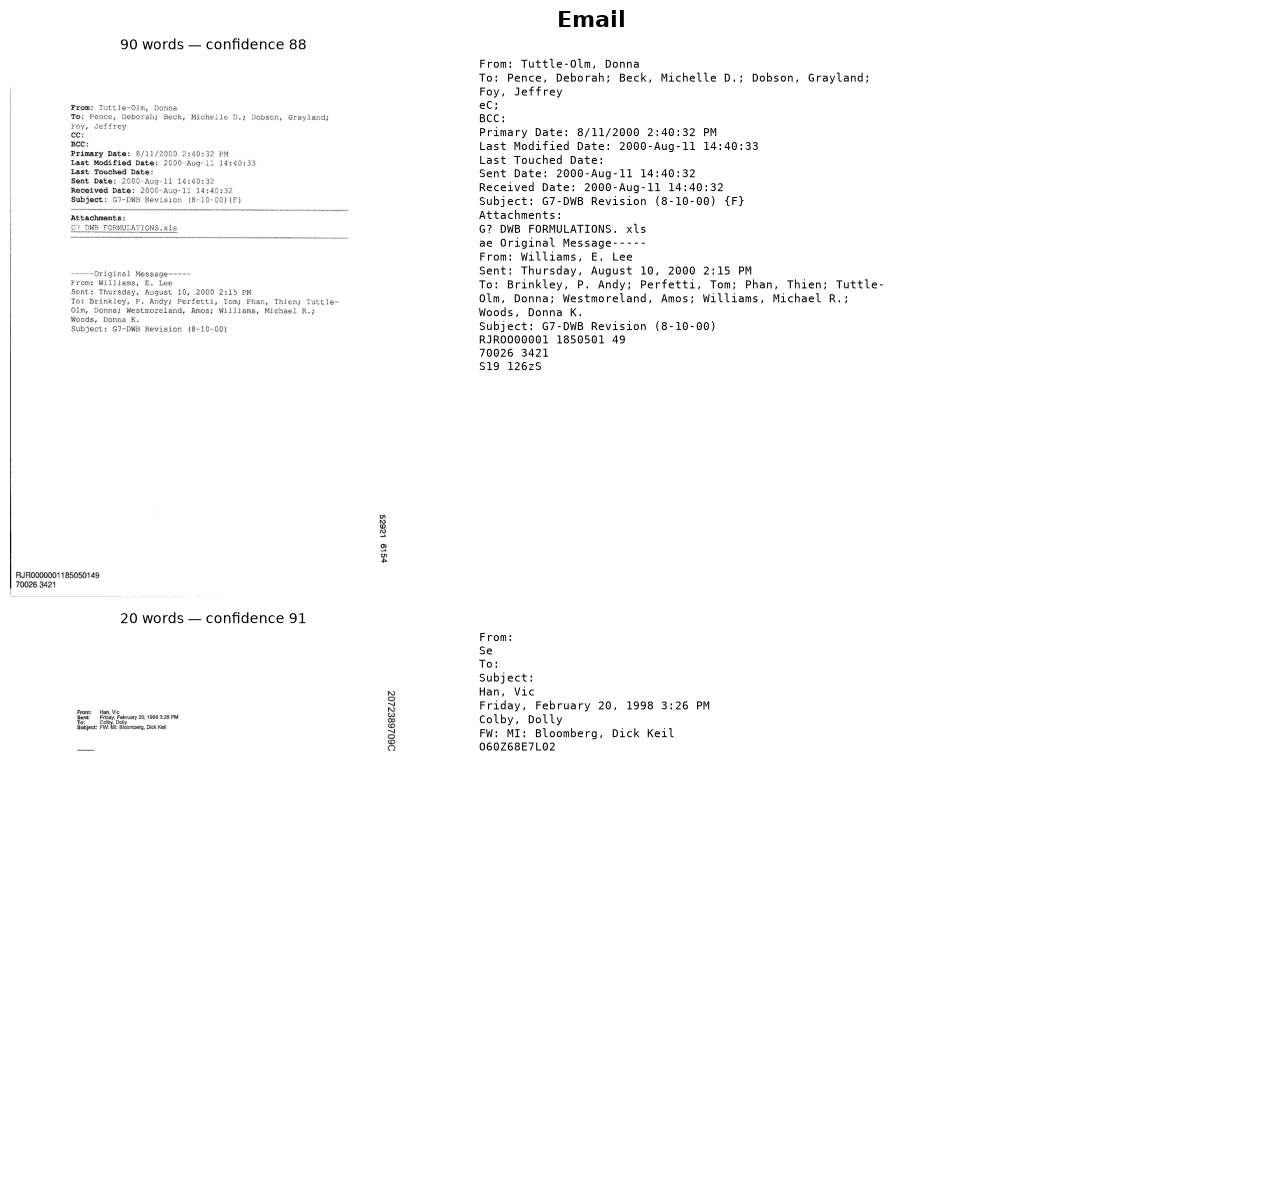

In [30]:
display_class(ocr,'Email')

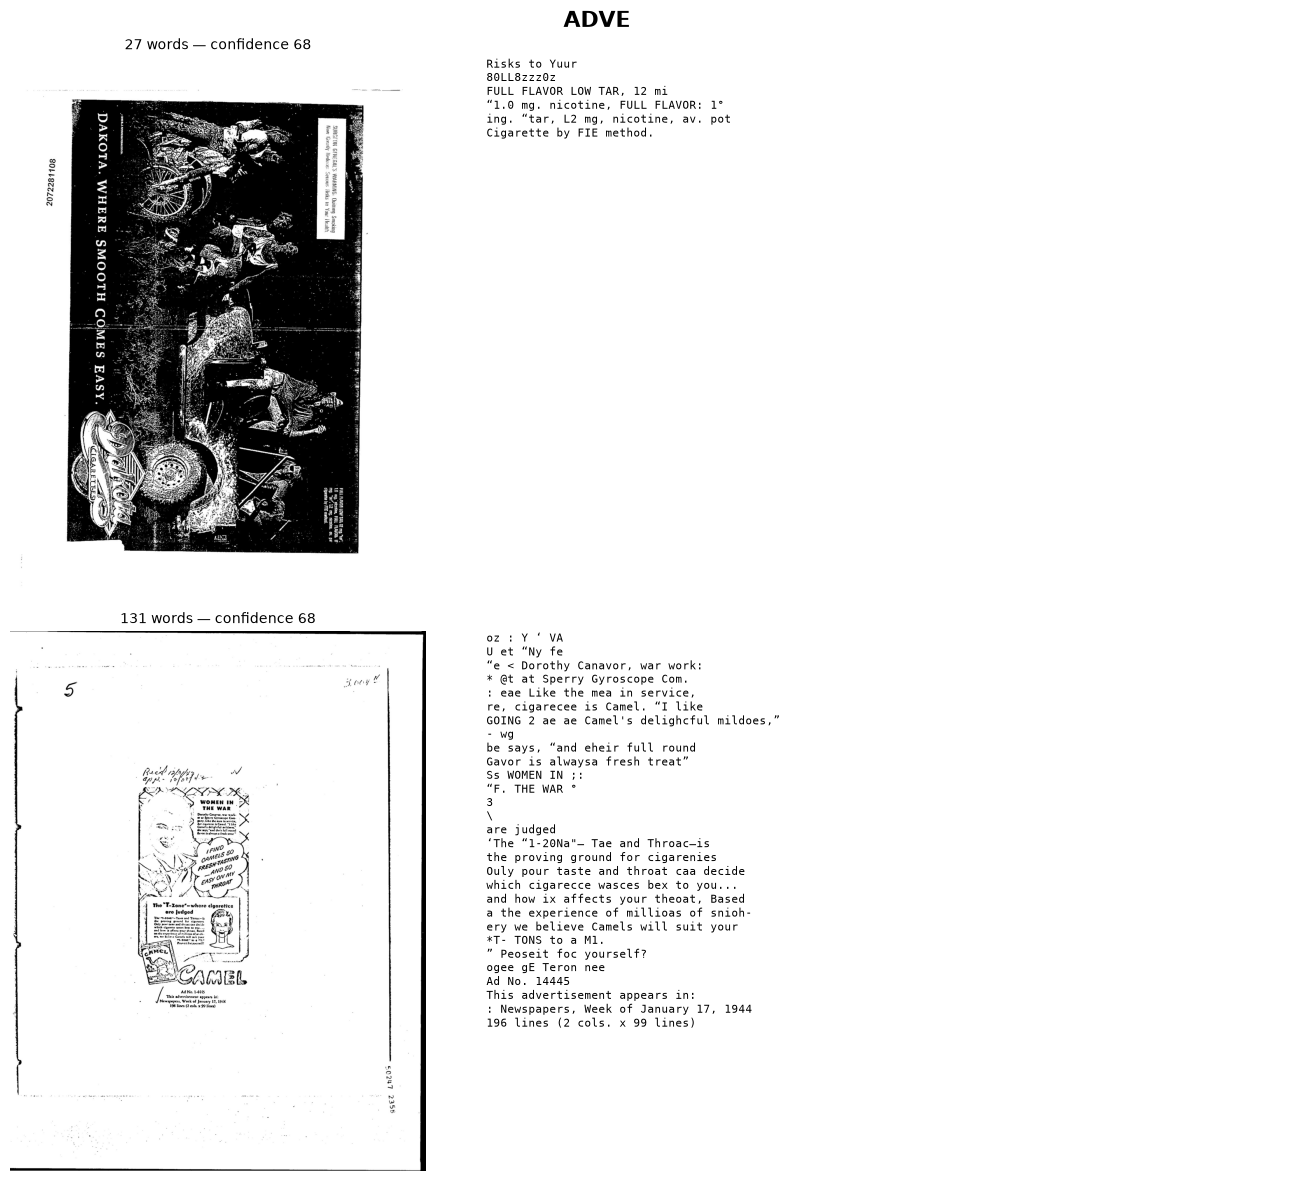

In [31]:
display_class(ocr,'ADVE')

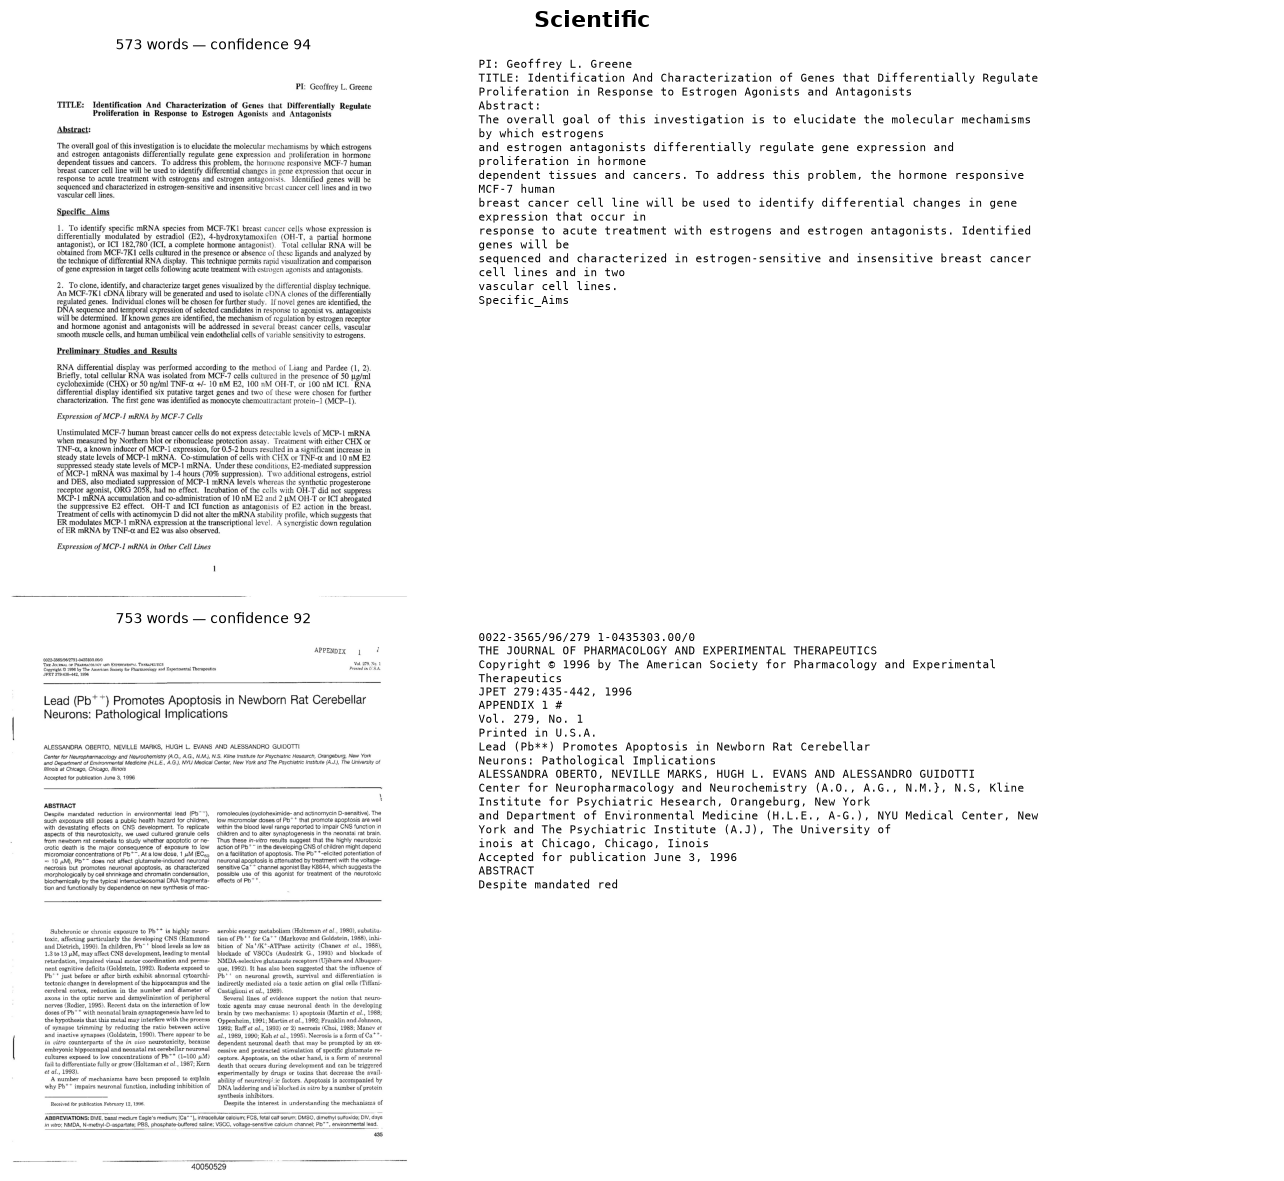

In [32]:
display_class(ocr,'Scientific')

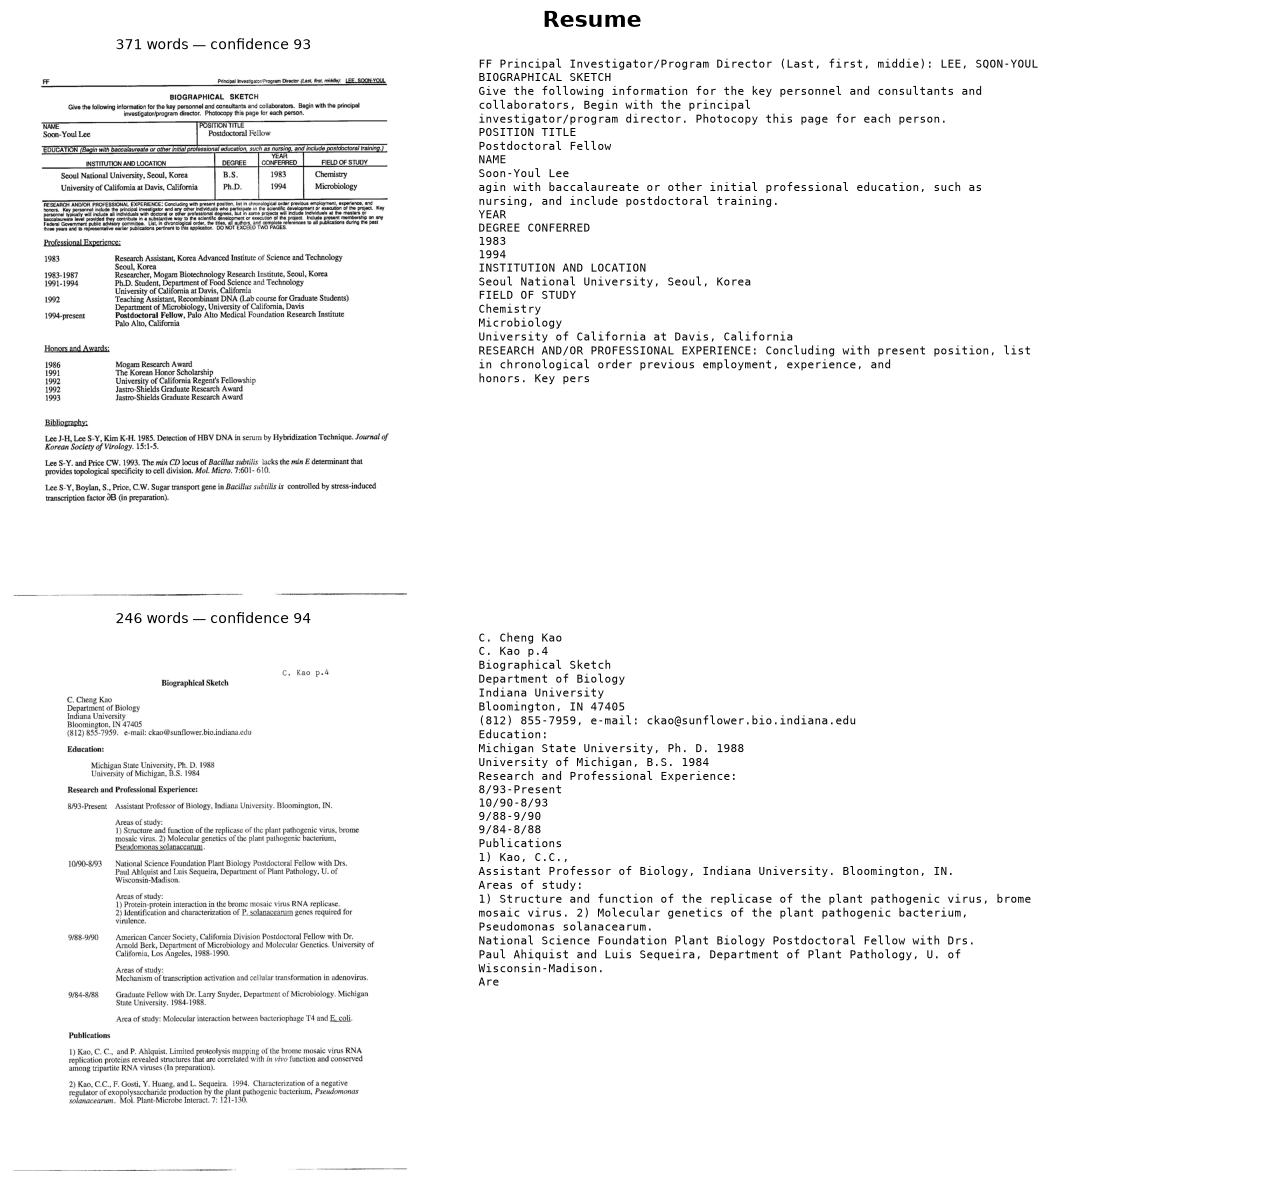

In [33]:
display_class(ocr,'Resume')

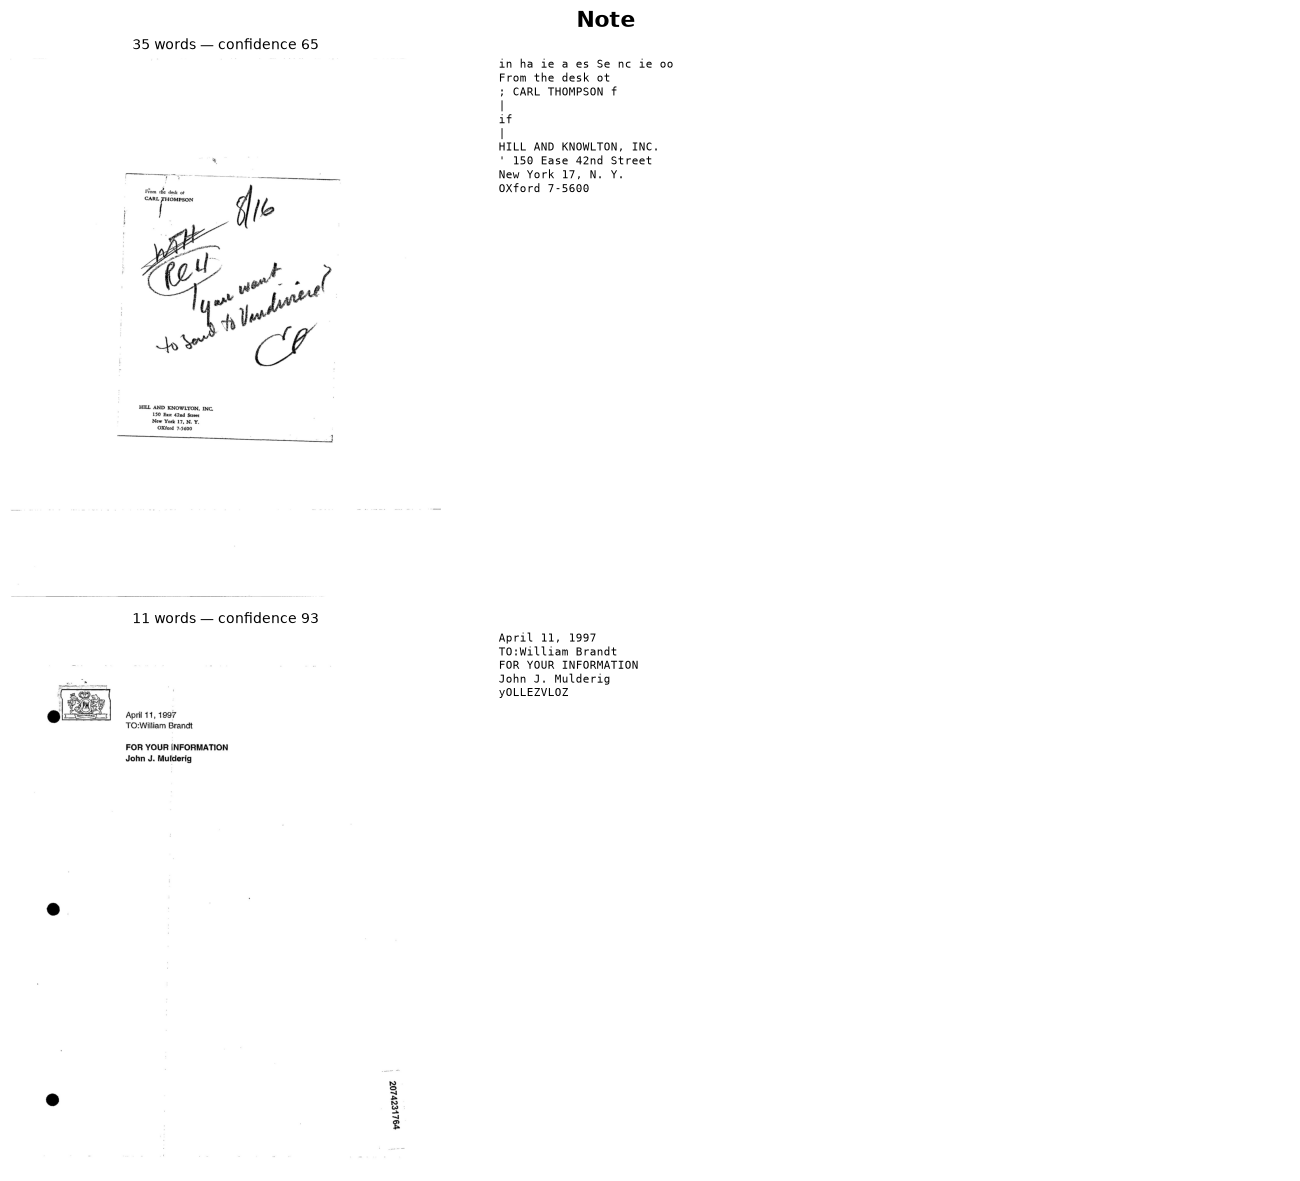

In [34]:
display_class(ocr,'Note')

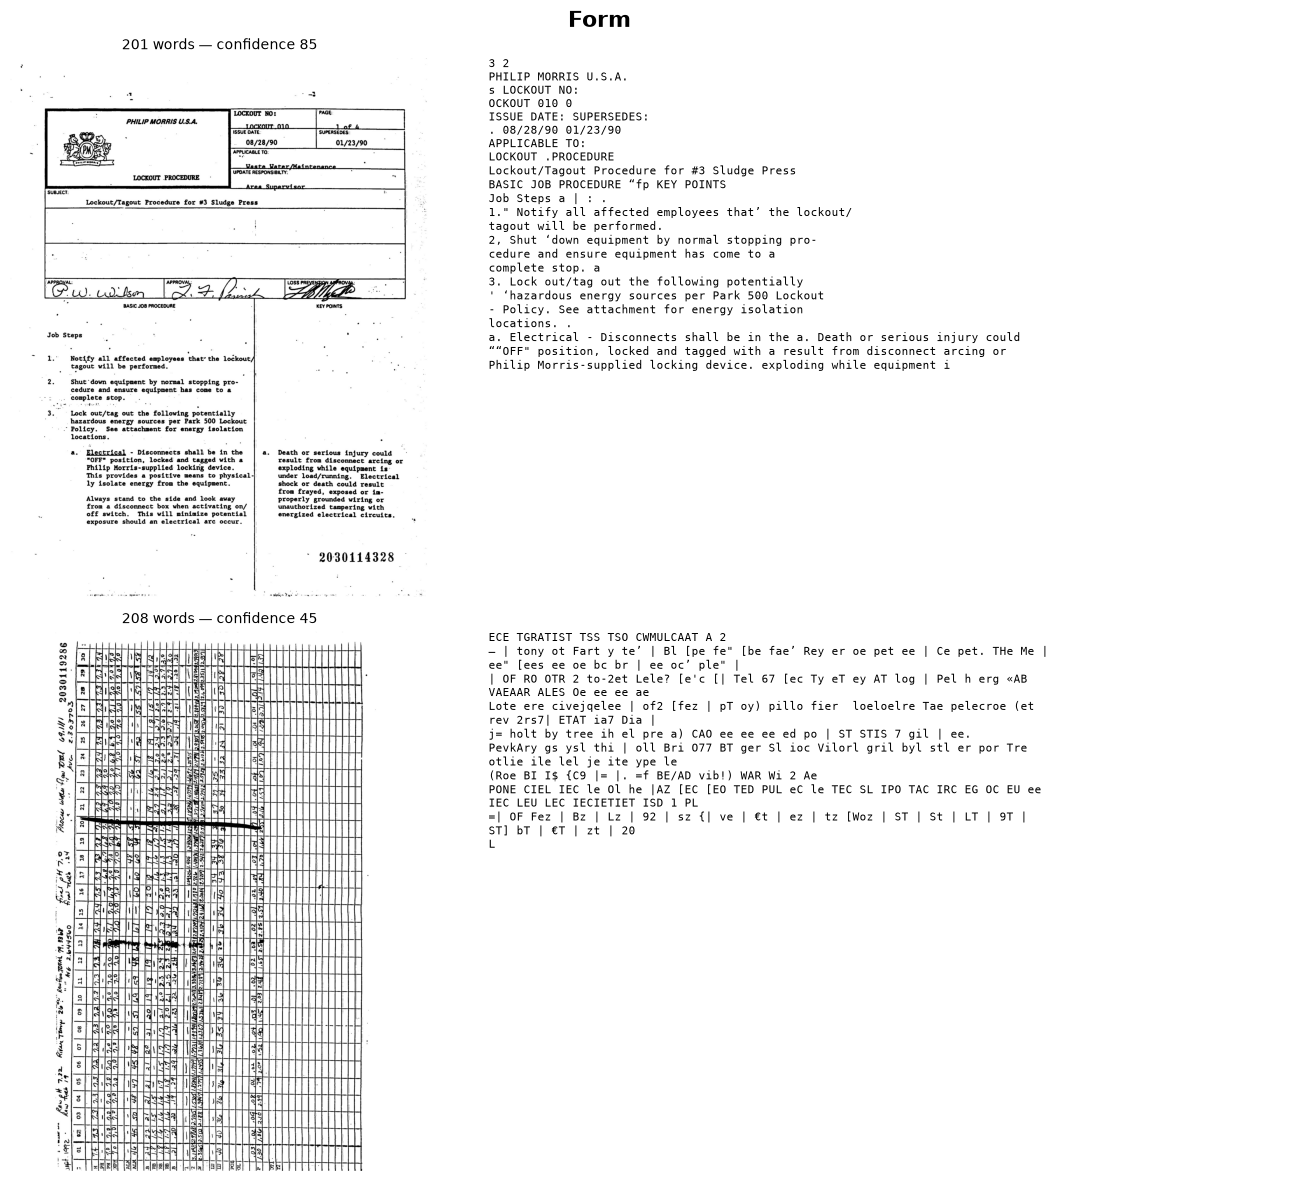

In [35]:
display_class(ocr,'Form')

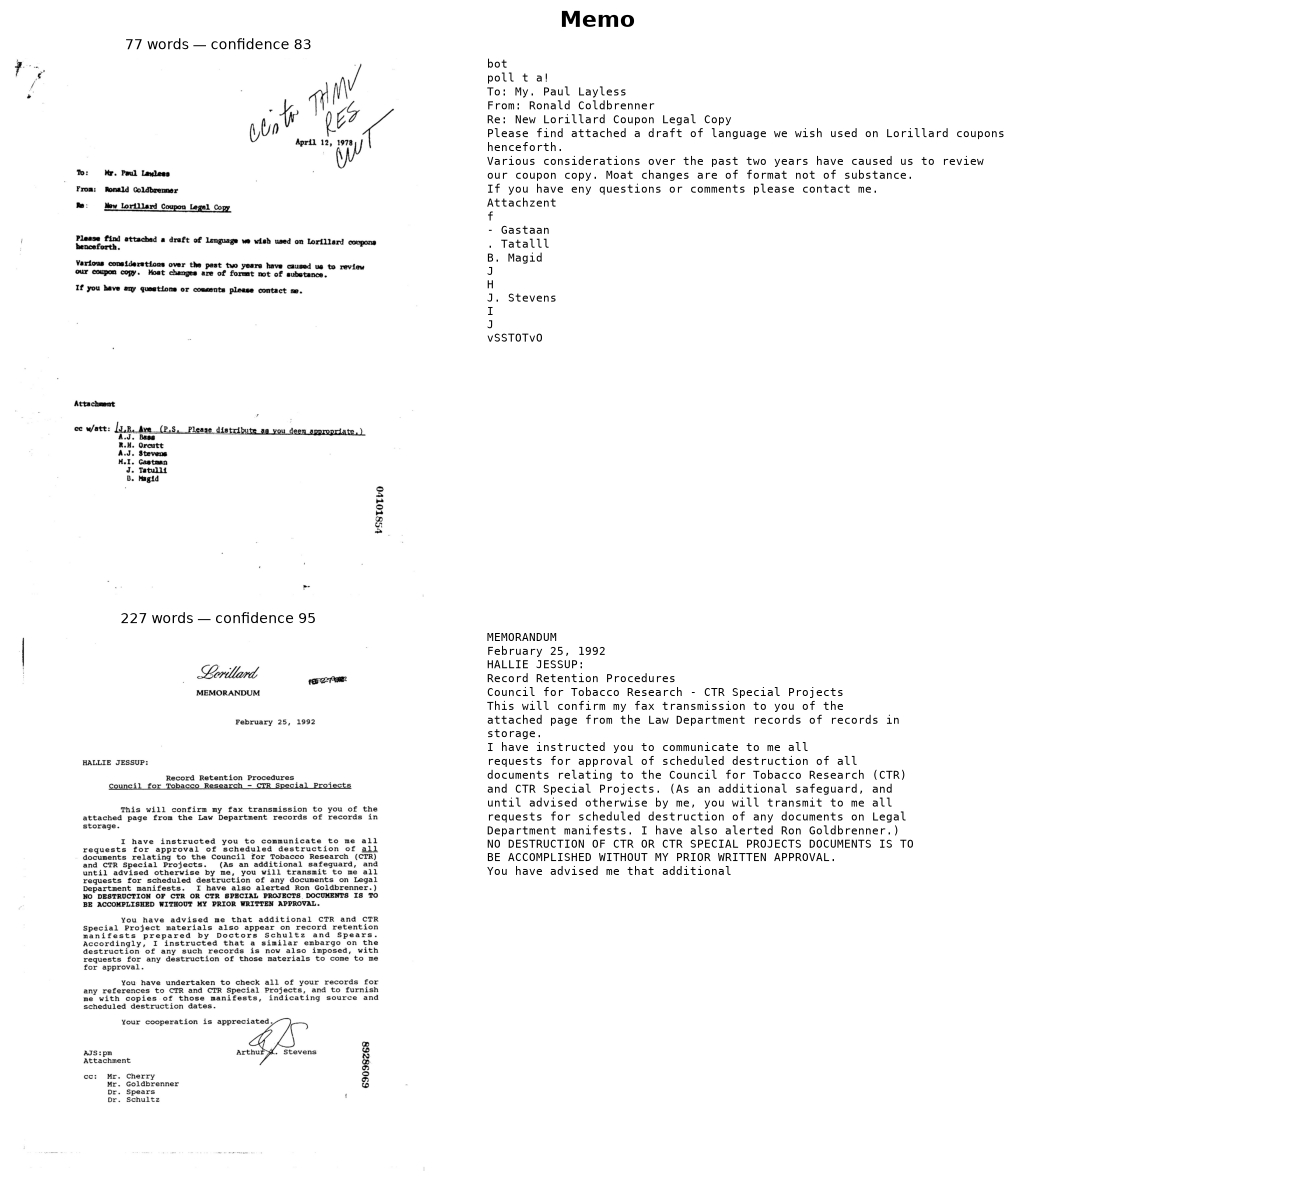

In [36]:
display_class(ocr,'Memo')

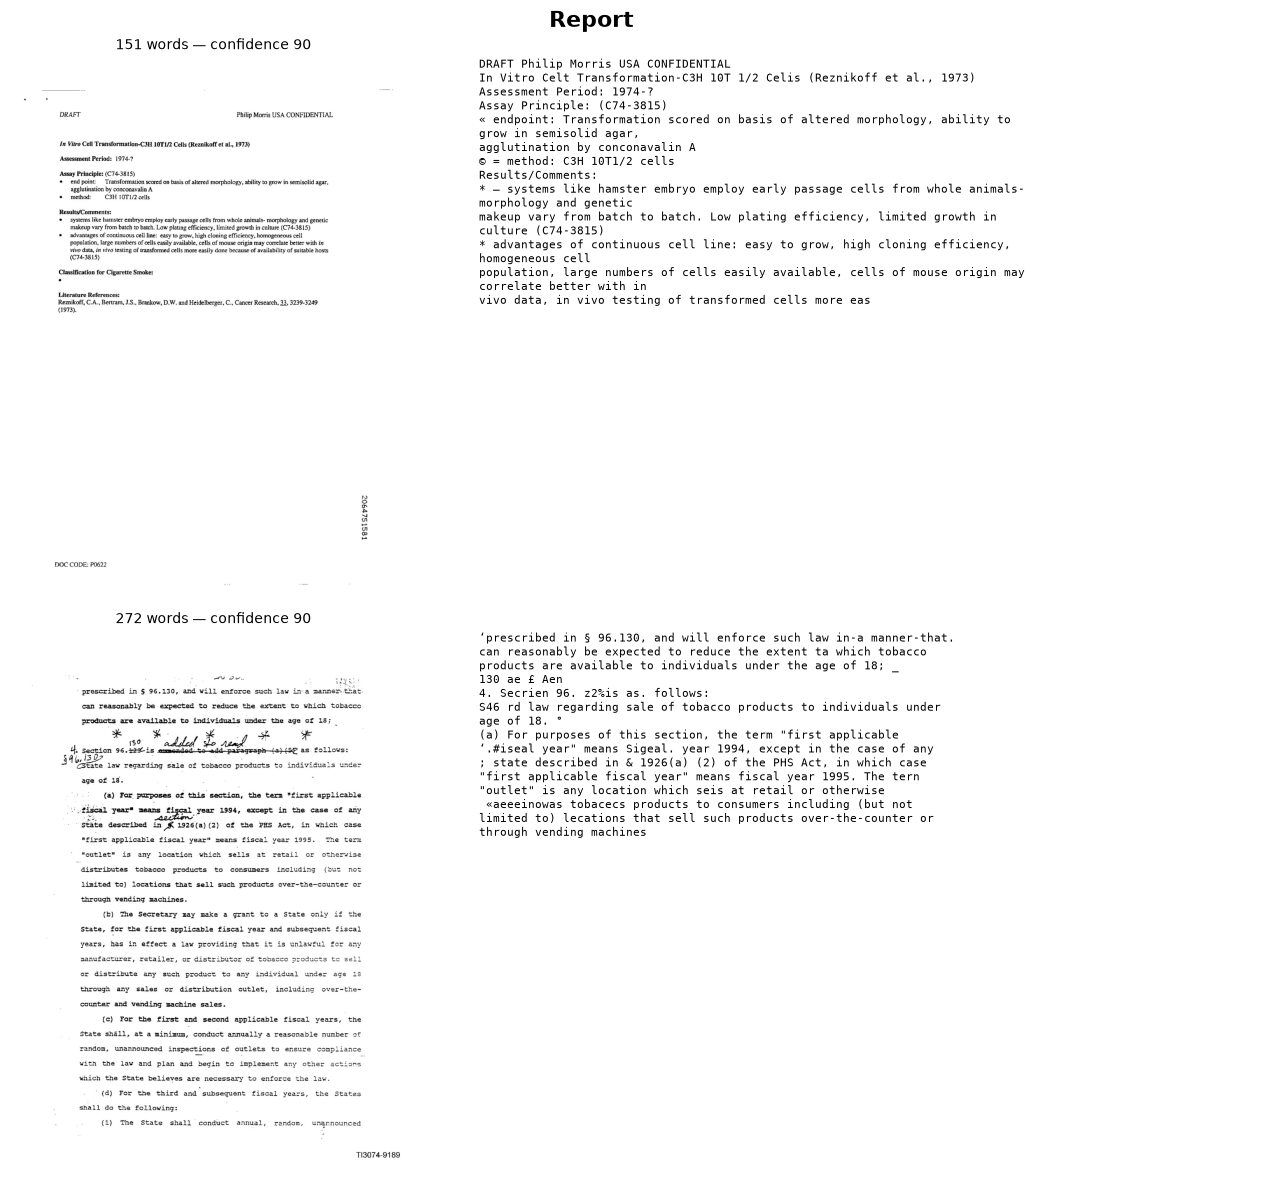

In [37]:
display_class(ocr,'Report')

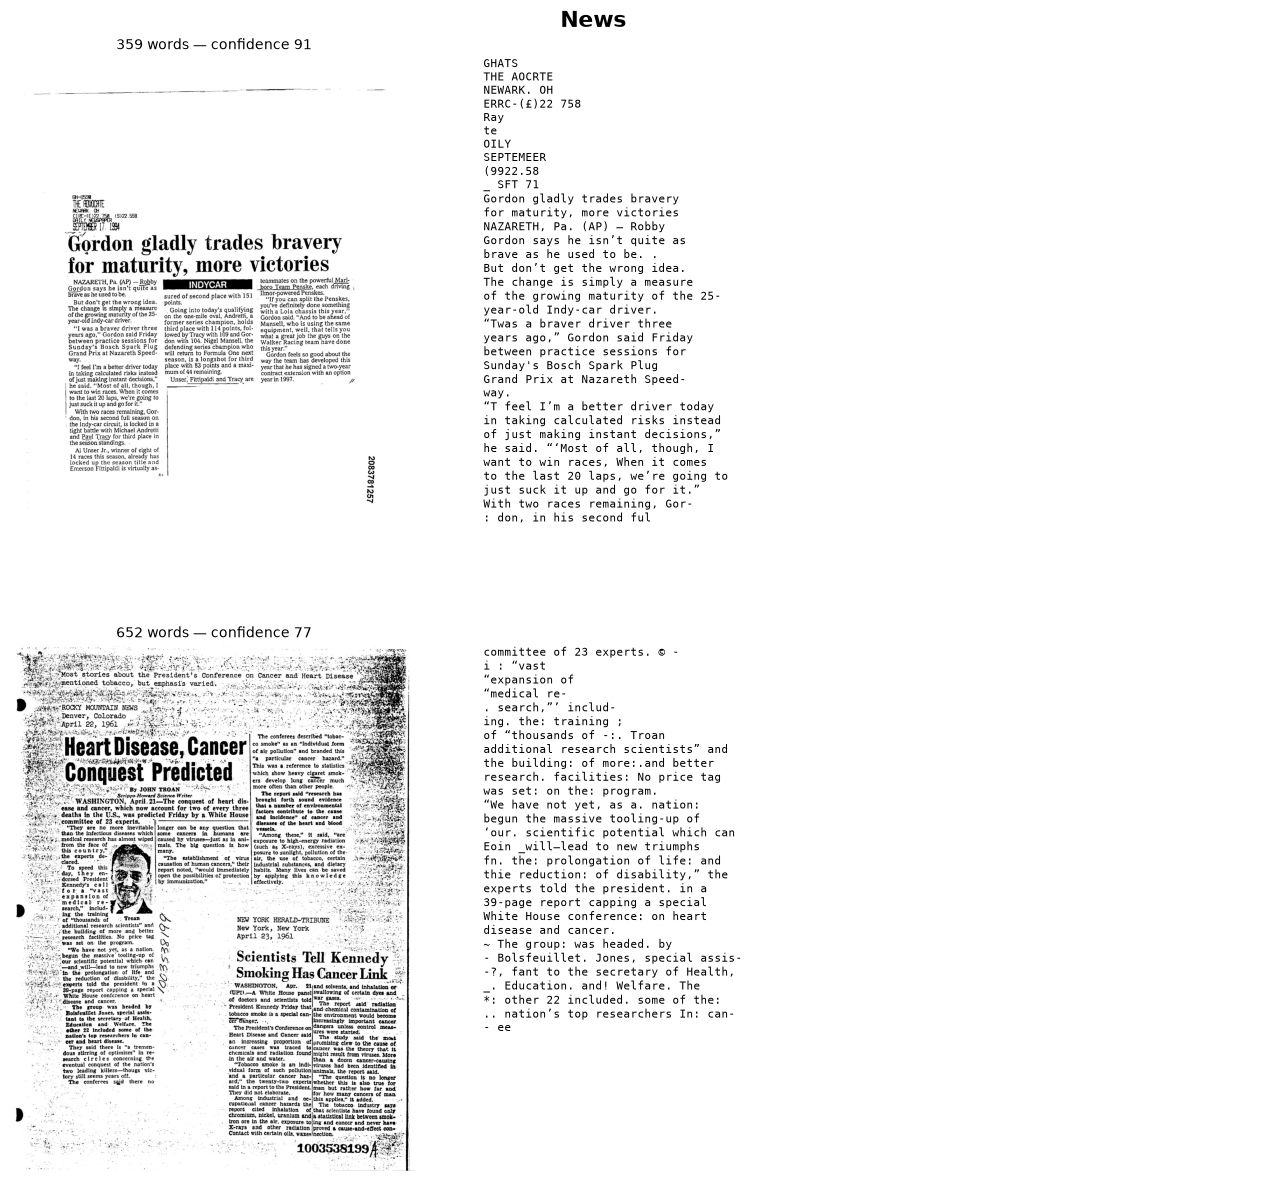

In [38]:
display_class(ocr,'News')

In [42]:
def osd_class(ocr, label):
    groupe = ocr[ocr["label"] == label]
    if groupe.empty:
        print(f"Class '{label}' not found. Classes available: {sorted(ocr['label'].unique())}")
        return None

    osd_results = []
    for _, r in groupe.iterrows():
        img = Image.open(root_path / path_images / r["path"])
        try:
            osd = pytesseract.image_to_osd(img, output_type=pytesseract.Output.DICT)
            osd_results.append({
                "path": r["path"],
                "orientation": osd["orientation"],          # angle détecté
                "rotate": osd["rotate"],                    # rotation à appliquer pour redresser
                "orientation_conf": osd["orientation_conf"],
                "script": osd["script"],
                "script_conf": osd["script_conf"],
            })
        except pytesseract.TesseractError as e:
            osd_results.append({"path": r["path"], "error": str(e)})

    return pd.DataFrame(osd_results)

In [43]:
osd_class(ocr, "Form")

,path,orientation,rotate,orientation_conf,script,script_conf
0,train/2030114328.jpg,0,0,1.56,Latin,10.93
1,test/2030119286.jpg,90,270,1.30,Cyrillic,1.23


In [44]:
osd_class(ocr, "ADVE")

,path,error,orientation,rotate,orientation_conf,script,script_conf
0,train/2072281108.jpg,"(1, 'Estimating resolution as 223 Warning. Inv...",NaN,NaN,NaN,NaN,NaN
1,val/502472358.jpg,NaN,0.0,0.0,1.23,Cyrillic,0.52


## OCR Exploration — Conclusions

> Scope: a small sample (2 documents each for Report, Note, Form, News and ADVE). These observations are qualitative and will be quantified once OCR has run on the full dataset.

### 1. Setup
- **Tesseract 5.5.3** (the OCR engine, installed at system level via Homebrew) with the `eng` and `osd` language data.
- **pytesseract** is only a Python wrapper that calls the Tesseract binary. It is declared in `pyproject.toml`, but Tesseract itself must be installed separately (this matters for the Docker image in Phase 5).
- OCR output can vary across Tesseract versions: the same version must be used for training and inference.

### 2. Performance
- About **1.1 s per image**, i.e. about **50 minutes** for the 2,737 documents.
- Running it locally is acceptable; Kaggle is not needed for this step.
- This cost justifies a **cache**: OCR must never be recomputed unnecessarily.

### 3. OCR quality by document type
- **Typed, clean documents** (e.g. Report): near-perfect text.
- **Handwriting** (Note): handwritten content is lost entirely. However, the **printed parts** (e.g. "From the desk of…", "FOR YOUR INFORMATION") are read correctly and are highly characteristic of the class.
- **Handwritten annotations** on printed pages also corrupt the nearby printed text ("Secrien 96", "Sigeal").
- **Multi-column layouts** (News, Form): columns are sometimes merged, and noisy scans produce many errors. Yet **discriminative keywords survive** ("cancer", "president", "research"…).
- **Advertisements** (ADVE): little text, but very telling (e.g. "tar", "nicotine", "This advertisement appears in: Newspapers").
- **Takeaway**: even noisy OCR keeps class-specific vocabulary, so a TF-IDF text baseline is promising.

### 4. Noise in the extracted text
- **Bates numbers** (archive IDs printed vertically in the margin) are read sideways and produce garbage tokens (e.g. `yOLLEZVLOZ`). They appear on almost every page and carry no class information.
- Clipping stamps and scan artifacts produce similar noise.
- These will need to be handled in the **text cleaning** step.

### 5. Quality indicators
- **Mean confidence alone is misleading**: a near-blank Note scored 93 with only 11 words.
- **Word count alone is misleading**: a rotated Form produced 208 "words", all garbage (confidence 45).
- A failed OCR is detected more reliably by **combining both** indicators.

### 6. Rotated pages
- Some pages have **rotated content** while the image itself is in portrait format (one Form, one ADVE). The aspect-ratio check from the EDA could not detect them.
- On these pages, OCR fails (garbage text, or key content such as the advertising slogan is lost).
- **Tesseract OSD is unreliable on this dataset**:
  - low orientation confidence, even when the detected angle is correct;
  - wrong script detection ("Cyrillic" on English documents);
  - outright failure on pages with little text (the rotated ADVE), which is precisely the case where it is needed.
- The **frequency** of rotated pages is unknown. The options (ignore and document / rotate only above an OSD confidence threshold / OCR in all 4 orientations, about ×4 cost) will be chosen **after** measuring it on the full OCR run (inspect the lowest-confidence documents).

### 7. Decisions for the OCR step
- The OCR code lives in the **package** (`docs_classifier/etl/transform/ocr.py`), not in a notebook.
- A single `image_to_data` call per image provides both the words and their confidences (calling OCR twice would double the runtime).
- Two functions: one calls Tesseract (slow, external), and one **pure** function computes text, mean confidence and word count from the raw output (testable without Tesseract).
- **Cache**: one JSON file per document in `data/interim/ocr/` (not versioned in Git), storing the path, text, mean confidence, word count and OCR settings (including the Tesseract version).
  - Documents already cached are skipped, so the run can **resume** after a crash (idempotence).
  - Errors are caught **per document** and do not stop the run.
  - The JSON files are then **consolidated into a single Parquet file** for analysis and for the rest of the pipeline.
- The run is first tested on **10 documents** before processing the full dataset.
- The page segmentation mode (`psm`) is to be explored later, to address merged columns.